# Chess Atlas — Training Pipeline

**Model:** MobileNetV3-Small (torchvision) — fine-tuned for 13-class chess piece classification  
**Checkpoint format:** TorchScript (`.pt`) — framework-agnostic, no class definition needed at inference  
**Split source:** `split_assignments.csv` — never recomputed here, always loaded

### Notebook flow
```
0 · Config & Seeding
1 · Dataset & DataLoaders  (augmentation lives here, train only)
2 · Model definition        (MobileNetV3-Small, frozen backbone → unfreeze schedule)
3 · Training loop           (AdamW + CosineAnnealingLR + early stopping)
4 · Evaluation              (F1 per class, macro/weighted, confusion matrix)
5 · Save checkpoint         (TorchScript + ONNX export for fast inference)
6 · Reproduce check         (reload model, verify identical val F1)
```

> **Rules enforced here:**  
> - Augmentation is applied **only** to train split  
> - Normalization stats are computed from **train split only**  
> - `test` split is loaded but **never evaluated** until Cell `4b` — the final cell  
> - Every random op is seeded; results are reproducible on re-run

## 0 · Config & Seeding

In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os, json, random, time, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.transforms import functional as TF

from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Master config — change only here ──────────────────────────────────────────
CFG = dict(
    # Paths
    dataset_root = Path('/home/amicus/Desktop/ChessCVModel/data/final_dataset'),
    split_csv    = Path('/home/amicus/Desktop/ChessCVModel/data/final_dataset/split_assignments.csv'),
    output_dir     = Path('runs'),

    # Reproducibility
    seed           = 42,

    # Input
    img_size       = 224,                # MobileNetV3 canonical input

    # Training
    batch_size     = 64,
    num_workers    = 4,
    epochs         = 60,
    lr             = 3e-4,
    weight_decay   = 1e-4,
    label_smoothing= 0.05,

    # Backbone unfreeze schedule
    # With only ~4400 unique training images, fine-tuning 927K backbone params
    # risks overfitting. The head-only run already hit 0.9944 F1 before unfreeze,
    # and the full unfreeze only added +0.005. Keep frozen unless head plateaus
    # below ~0.97 after several epochs — in that case try partial unfreeze of
    # only the last backbone block (features[-1]) rather than all params.
    #
    # Set unfreeze_epoch > epochs to never unfreeze (current default).
    # Set unfreeze_epoch = 10 to restore previous behaviour.
    unfreeze_epoch = 10,                # effectively disabled — backbone stays frozen
    backbone_lr_multiplier = 0.1,        # used only if unfreeze_epoch is reached

    # Early stopping
    patience       = 15,                 # slightly more patience: harder augmentation
                                         # means head converges more slowly

    # Augmentation — arrow/highlight overlay
    aug_arrow_prob    = 0.40,            # probability of drawing streamer highlight
    aug_arrow_both_p  = 0.10,            # P(crossing) given arrow is drawn
    aug_arrow_alpha   = (0.30, 1.0),     # opacity range — includes fully opaque overlays

    # Augmentation — JPEG compression blockiness
    aug_jpeg_prob     = 0.50,            # probability of applying JPEG degradation
    aug_jpeg_quality  = (15, 85),        # uniform-random quality level in this range

    # Class-balanced sampling
    # weight_i = (1 / count_i) ^ sampler_power
    #   0.0 = no reweighting, 0.5 = sqrt-inverse, 1.0 = full inverse
    # sampler_multiplier expands epoch size so rare classes get more augmented
    # passes without reducing the majority class absolute count.
    sampler_power       = 0.75,
    sampler_multiplier  = 1.0,           # epoch = 2× original train size (~8800 draws)
)

# ── Seeding — covers Python, NumPy, PyTorch, CUDA ─────────────────────────────
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

# ── Create run directory (timestamped) ────────────────────────────────────────
RUN_ID  = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR = CFG['output_dir'] / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f'Run dir: {RUN_DIR}')

with open(RUN_DIR / 'config.json', 'w') as f:
    json.dump({k: str(v) for k, v in CFG.items()}, f, indent=2)

Device : cuda
PyTorch: 2.10.0
Run dir: runs/20260305_222209


## 1 · Dataset & DataLoaders

In [2]:
# ── Label map (alphabetical → deterministic) ───────────────────────────────────
LABELS = [
    'BlackBishop', 'BlackKing',   'BlackKnight', 'BlackPawn',
    'BlackQueen',  'BlackRook',   'Empty',
    'WhiteBishop', 'WhiteKing',   'WhiteKnight', 'WhitePawn',
    'WhiteQueen',  'WhiteRook',
]
NUM_CLASSES = len(LABELS)
LABEL2IDX   = {l: i for i, l in enumerate(LABELS)}
IDX2LABEL   = {i: l for l, i in LABEL2IDX.items()}

print(f'{NUM_CLASSES} classes: {LABELS}')

13 classes: ['BlackBishop', 'BlackKing', 'BlackKnight', 'BlackPawn', 'BlackQueen', 'BlackRook', 'Empty', 'WhiteBishop', 'WhiteKing', 'WhiteKnight', 'WhitePawn', 'WhiteQueen', 'WhiteRook']


In [3]:
# ── Streamer Arrow / Highlight Augmentation ────────────────────────────────────
# Simulates the colored annotation arrows (Gotham's green/red move arrows,
# square highlights) that partially or fully occlude pieces in real screenshots.
# Applied as a callable that works on uint8 HWC NumPy arrays.

class StreamerHighlightAug:
    """
    Draws semi-transparent to fully-opaque horizontal, vertical, or crossing
    color bands over a chess square image to simulate streamer annotation arrows.

    alpha_range upper bound of 1.0 covers fully opaque overlays — common when
    streamers use solid highlight squares rather than translucent move arrows.

    Designed to be inserted into a torchvision transforms pipeline via
    transforms.Lambda after ToTensor is NOT yet applied (operates on PIL→numpy).
    """

    # Chess streamer palette: green (safe), red (danger), blue (info),
    # orange (caution), yellow (highlight) — matches Gotham's typical palette
    COLORS = [
        (0,   200,  0),    # green  — most common (Gotham's move arrows)
        (220,  30, 30),    # red
        (30,   80, 220),   # blue
        (255, 165,  0),    # orange
        (240, 240,  0),    # yellow
    ]

    def __init__(
        self,
        apply_prob:       float = 0.40,
        alpha_range:      tuple = (0.30, 1.0),  # includes fully opaque
        thickness_range:  tuple = (0.20, 0.50),
        both_cross_prob:  float = 0.10,
    ):
        self.apply_prob      = apply_prob
        self.alpha_range     = alpha_range
        self.thickness_range = thickness_range
        self.both_cross_prob = both_cross_prob

    def __call__(self, img_np: np.ndarray) -> np.ndarray:
        """img_np: uint8 HWC RGB array. Returns same shape/dtype."""
        if np.random.random() > self.apply_prob:
            return img_np
        return self._draw(img_np)

    def _draw(self, img_np: np.ndarray) -> np.ndarray:
        h, w = img_np.shape[:2]
        overlay = img_np.copy()

        color = self.COLORS[np.random.randint(len(self.COLORS))]
        alpha = np.random.uniform(*self.alpha_range)
        thick = np.random.uniform(*self.thickness_range)

        # Orientation: H-only, V-only, or crossing (rarer)
        p_cross = self.both_cross_prob
        p_single = (1.0 - p_cross) / 2.0
        orientation = np.random.choice(
            ['H', 'V', 'X'],
            p=[p_single, p_single, p_cross]
        )

        if orientation in ('H', 'X'):
            rect_h  = max(1, int(h * thick))
            y_start = np.random.randint(0, max(1, h - rect_h))
            # OpenCV uses BGR; img_np is RGB — pass RGB tuple, convert inline
            cv2.rectangle(
                overlay,
                (0, y_start), (w, y_start + rect_h),
                (color[2], color[1], color[0]),  # RGB→BGR for cv2
                -1
            )

        if orientation in ('V', 'X'):
            rect_w  = max(1, int(w * thick))
            x_start = np.random.randint(0, max(1, w - rect_w))
            cv2.rectangle(
                overlay,
                (x_start, 0), (x_start + rect_w, h),
                (color[2], color[1], color[0]),
                -1
            )

        # Alpha blend: overlay*alpha + original*(1-alpha)
        # When alpha==1.0 this becomes a fully opaque solid band.
        blended = cv2.addWeighted(overlay, alpha, img_np, 1.0 - alpha, 0)
        return blended

    def visualize_samples(self, img_np: np.ndarray, n: int = 8):
        """Quick visual sanity check — call manually to verify aug looks right."""
        orig_prob = self.apply_prob
        self.apply_prob = 1.0          # force every sample to have aug
        fig, axes = plt.subplots(2, n // 2, figsize=(n * 1.5, 4))
        for ax in axes.flat:
            out = self._draw(img_np.copy())
            ax.imshow(out); ax.axis('off')
        fig.suptitle('StreamerHighlightAug samples (apply_prob forced=1.0)', fontsize=11)
        plt.tight_layout(); plt.show()
        self.apply_prob = orig_prob


# ── JPEG Compression Augmentation ─────────────────────────────────────────────
# Simulates 8×8 DCT blockiness that appears when video frames are JPEG-compressed
# at low quality — common in cropped YouTube thumbnails and low-bitrate streams.

class JPEGCompressAug:
    """Encode to JPEG at a random quality and decode back — introduces blockiness."""

    def __init__(self, apply_prob: float = 0.50, quality_range: tuple = (15, 85)):
        self.apply_prob    = apply_prob
        self.quality_range = quality_range

    def __call__(self, img_np: np.ndarray) -> np.ndarray:
        """img_np: uint8 HWC RGB array. Returns same shape/dtype."""
        if np.random.random() > self.apply_prob:
            return img_np
        quality = int(np.random.randint(self.quality_range[0], self.quality_range[1] + 1))
        bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        _, enc = cv2.imencode('.jpg', bgr, [cv2.IMWRITE_JPEG_QUALITY, quality])
        dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
        return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)


arrow_aug = StreamerHighlightAug(
    apply_prob      = CFG['aug_arrow_prob'],
    alpha_range     = CFG['aug_arrow_alpha'],
    both_cross_prob = CFG['aug_arrow_both_p'],
)
jpeg_aug = JPEGCompressAug(
    apply_prob    = CFG['aug_jpeg_prob'],
    quality_range = CFG['aug_jpeg_quality'],
)
print('StreamerHighlightAug ready (alpha up to 1.0 — fully opaque)')
print('JPEGCompressAug ready')

StreamerHighlightAug ready (alpha up to 1.0 — fully opaque)
JPEGCompressAug ready


In [4]:
# ── Compute normalization mean/std from TRAIN split only ──────────────────────
# We do a fast single-pass over raw train images (no aug) to get dataset stats.
# These values are then hard-coded into both train and val/test transforms.

split_df = pd.read_csv(CFG['split_csv'])
train_df = split_df[split_df['split'] == 'train'].reset_index(drop=True)
val_df   = split_df[split_df['split'] == 'val'].reset_index(drop=True)
test_df  = split_df[split_df['split'] == 'test'].reset_index(drop=True)

IMG_SIZE = CFG['img_size']

def compute_mean_std(df: pd.DataFrame, root: Path, size: int = 64) -> tuple:
    """Fast mean/std computation using 64px resize (stats are scale-invariant)."""
    pixel_sum    = np.zeros(3, dtype=np.float64)
    pixel_sq_sum = np.zeros(3, dtype=np.float64)
    n_pixels = 0

    for fp in df['filepath']:
        path = root / fp
        img  = cv2.imread(str(path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (size, size)).astype(np.float32) / 255.0
        pixel_sum    += img.reshape(-1, 3).sum(0)
        pixel_sq_sum += (img ** 2).reshape(-1, 3).sum(0)
        n_pixels     += size * size

    mean = pixel_sum    / n_pixels
    std  = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)
    return tuple(mean.tolist()), tuple(std.tolist())

print('Computing normalization stats from train split...', end=' ')
NORM_MEAN, NORM_STD = compute_mean_std(train_df, CFG['dataset_root'])
print('done')
print(f'  mean = {[round(v,4) for v in NORM_MEAN]}')
print(f'  std  = {[round(v,4) for v in NORM_STD]}')

# Persist so inference scripts can load without re-computing
with open(RUN_DIR / 'norm_stats.json', 'w') as f:
    json.dump({'mean': list(NORM_MEAN), 'std': list(NORM_STD)}, f, indent=2)

Computing normalization stats from train split... done
  mean = [0.7676, 0.6587, 0.5281]
  std  = [0.1998, 0.2, 0.1923]


In [5]:
# ── Transforms ────────────────────────────────────────────────────────────────
# Train:  JPEG aug → StreamerHighlight → geometric aug → color aug → normalize
# Val/Test: deterministic resize + normalize only

from torchvision.transforms import (
    Compose, Resize, ToTensor, Normalize,
    RandomHorizontalFlip, RandomVerticalFlip,
    ColorJitter, RandomErasing, RandomAffine,
    RandomAutocontrast, Lambda,
)
from PIL import Image as PILImage

def np_to_pil(x):  return PILImage.fromarray(x.astype(np.uint8))
def pil_to_np(x):  return np.array(x)

train_transform = Compose([
    # 1. Load as PIL → convert to numpy for cv2-based augmentations
    Lambda(pil_to_np),

    # 2. JPEG compression blockiness (simulate low-quality video crops)
    #    Applied before resize so block artifacts scale naturally with content.
    Lambda(jpeg_aug),

    # 3. Streamer arrow/highlight overlay (semi-transparent to fully opaque)
    Lambda(arrow_aug),

    Lambda(np_to_pil),

    # 4. Geometric augmentations
    Resize((IMG_SIZE, IMG_SIZE)),
    RandomHorizontalFlip(p=0.3),
    RandomVerticalFlip(p=0.1),           # uncommon but valid for board crops
    # RandomAffine covers rotation + translation + scale in one pass:
    #   translate=(0.08, 0.08) → ±8% shift for off-center board slicing errors
    #   scale=(0.92, 1.08)     → slight zoom from aspect-ratio correction
    RandomAffine(
        degrees=5,
        translate=(0.08, 0.08),
        scale=(0.92, 1.08),
        fill=0,
    ),

    # 5. Color/appearance augmentations
    #    Stronger brightness/contrast to cover dark streams, HDR, and theme variation.
    ColorJitter(
        brightness=0.40,
        contrast=0.40,
        saturation=0.25,
        hue=0.08,
    ),
    # RandomAutocontrast handles extreme exposure cases (overexposed/underexposed)
    # that ColorJitter's additive brightness shift misses.
    RandomAutocontrast(p=0.20),

    # 6. Tensor conversion + normalize
    ToTensor(),
    Normalize(mean=NORM_MEAN, std=NORM_STD),

    # 7. Random erasing AFTER ToTensor (simulates occlusion/JPEG artifacts)
    RandomErasing(p=0.15, scale=(0.02, 0.15), ratio=(0.5, 2.0), value='random'),
])

val_transform = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    Normalize(mean=NORM_MEAN, std=NORM_STD),
])

# test_transform is identical to val — defined separately for clarity
test_transform = val_transform

print('Transforms defined')
print(f'  Train pipeline: {len(train_transform.transforms)} steps')
print(f'    - JPEG blockiness (p={CFG["aug_jpeg_prob"]}, q={CFG["aug_jpeg_quality"]})')
print(f'    - Arrow overlay   (p={CFG["aug_arrow_prob"]}, alpha={CFG["aug_arrow_alpha"]})')
print(f'    - RandomAffine    (rot=5°, translate=8%, scale=8%)')
print(f'    - ColorJitter     (brightness=0.40, contrast=0.40)')
print(f'    - RandomAutocontrast (p=0.20)')
print(f'  Val/Test pipeline: {len(val_transform.transforms)} steps (deterministic)')

Transforms defined
  Train pipeline: 13 steps
    - JPEG blockiness (p=0.5, q=(15, 85))
    - Arrow overlay   (p=0.4, alpha=(0.3, 1.0))
    - RandomAffine    (rot=5°, translate=8%, scale=8%)
    - ColorJitter     (brightness=0.40, contrast=0.40)
    - RandomAutocontrast (p=0.20)
  Val/Test pipeline: 3 steps (deterministic)


In [6]:
# ── Dataset ───────────────────────────────────────────────────────────────────

class ChessSquareDataset(Dataset):
    def __init__(self, df: pd.DataFrame, root: Path, transform=None):
        self.df        = df.reset_index(drop=True)
        self.root      = root
        self.transform = transform

    def __len__(self):  return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = self.root / row['filepath']
        label = LABEL2IDX[row['label']]

        # Load as RGB PIL Image (transform pipeline expects PIL)
        img = PILImage.open(path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label


# ── Class-balanced WeightedRandomSampler ──────────────────────────────────────
# Each non-empty piece class is rare relative to Empty. The sampler assigns
# higher draw probability to rare classes so they appear more often per epoch,
# and each draw gets an independently-seeded random augmentation — effectively
# generating augmented copies without touching the data files.

def make_weighted_sampler(df: pd.DataFrame, power: float, multiplier: float) -> WeightedRandomSampler:
    """
    Build a WeightedRandomSampler for the given split DataFrame.

    weight_i = (1 / count(class_i)) ^ power

    power=0 → uniform (no reweighting)
    power=0.5 → sqrt-inverse (gentle balance)
    power=1.0 → full inverse (each class equally frequent)

    num_samples = len(df) * multiplier  → expanded epoch for more augmented passes.
    """
    class_counts = df['label'].value_counts().to_dict()
    sample_weights = np.array([
        (1.0 / class_counts[row['label']]) ** power
        for _, row in df.iterrows()
    ], dtype=np.float64)

    num_samples = int(len(df) * multiplier)
    return WeightedRandomSampler(
        weights     = torch.DoubleTensor(sample_weights),
        num_samples = num_samples,
        replacement = True,   # required — rare classes drawn multiple times per epoch
    )


def make_loaders(cfg: dict) -> tuple:
    train_ds = ChessSquareDataset(train_df, cfg['dataset_root'], train_transform)
    val_ds   = ChessSquareDataset(val_df,   cfg['dataset_root'], val_transform)
    test_ds  = ChessSquareDataset(test_df,  cfg['dataset_root'], test_transform)

    sampler = make_weighted_sampler(
        train_df,
        power      = cfg['sampler_power'],
        multiplier = cfg['sampler_multiplier'],
    )

    g = torch.Generator(); g.manual_seed(cfg['seed'])

    train_loader = DataLoader(
        train_ds,
        batch_size  = cfg['batch_size'],
        sampler     = sampler,          # replaces shuffle=True; sampler handles ordering
        num_workers = cfg['num_workers'],
        pin_memory  = True,
        generator   = g,
        persistent_workers = (cfg['num_workers'] > 0),
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg['batch_size'] * 2,
        shuffle=False, num_workers=cfg['num_workers'],
        pin_memory=True,
        persistent_workers=(cfg['num_workers'] > 0),
    )
    test_loader = DataLoader(
        test_ds, batch_size=cfg['batch_size'] * 2,
        shuffle=False, num_workers=cfg['num_workers'],
        pin_memory=True,
        persistent_workers=(cfg['num_workers'] > 0),
    )
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = make_loaders(CFG)

# ── Sampler diagnostics ───────────────────────────────────────────────────────
# Show effective sampling rate per class so the rebalancing effect is visible.
class_counts = train_df['label'].value_counts().to_dict()
effective_samples = int(len(train_df) * CFG['sampler_multiplier'])
total_weight = sum((1.0 / class_counts[c]) ** CFG['sampler_power'] for c in LABELS)
print(f'Train sampler  : power={CFG["sampler_power"]}, multiplier={CFG["sampler_multiplier"]}')
print(f'Epoch size     : {effective_samples} draws  (was {len(train_df)})')
print(f'\n{"Class":<15} {"Raw count":>9}  {"Raw %":>6}  {"Sampled ~":>9}  {"Sampled %":>9}')
print('-' * 55)
for cls in LABELS:
    raw_n   = class_counts.get(cls, 0)
    raw_pct = raw_n / len(train_df) * 100
    w       = (1.0 / raw_n) ** CFG['sampler_power'] if raw_n else 0
    sampled = effective_samples * w / total_weight
    samp_pct = sampled / effective_samples * 100
    print(f'{cls:<15} {raw_n:>9}  {raw_pct:>5.1f}%  {sampled:>9.0f}  {samp_pct:>8.1f}%')

print(f'\nVal batches   : {len(val_loader)}  ({len(val_loader.dataset)} samples)')
print(f'Test batches  : {len(test_loader)}  ({len(test_loader.dataset)} samples)')

Train sampler  : power=0.75, multiplier=2.0
Epoch size     : 225024 draws  (was 112512)

Class           Raw count   Raw %  Sampled ~  Sampled %
-------------------------------------------------------
BlackBishop          2016    1.8%      19983       8.9%
BlackKing            1696    1.5%      22748      10.1%
BlackKnight          1999    1.8%      20110       8.9%
BlackPawn           10075    9.0%       5978       2.7%
BlackQueen           1300    1.2%      27769      12.3%
BlackRook            2766    2.5%      15763       7.0%
Empty               72273   64.2%       1364       0.6%
WhiteBishop          2112    1.9%      19297       8.6%
WhiteKing            1737    1.5%      22344       9.9%
WhiteKnight          1964    1.7%      20378       9.1%
WhitePawn           10376    9.2%       5848       2.6%
WhiteQueen           1264    1.1%      28360      12.6%
WhiteRook            2934    2.6%      15081       6.7%

Val batches   : 161  (20544 samples)
Test batches  : 198  (25280 sampl

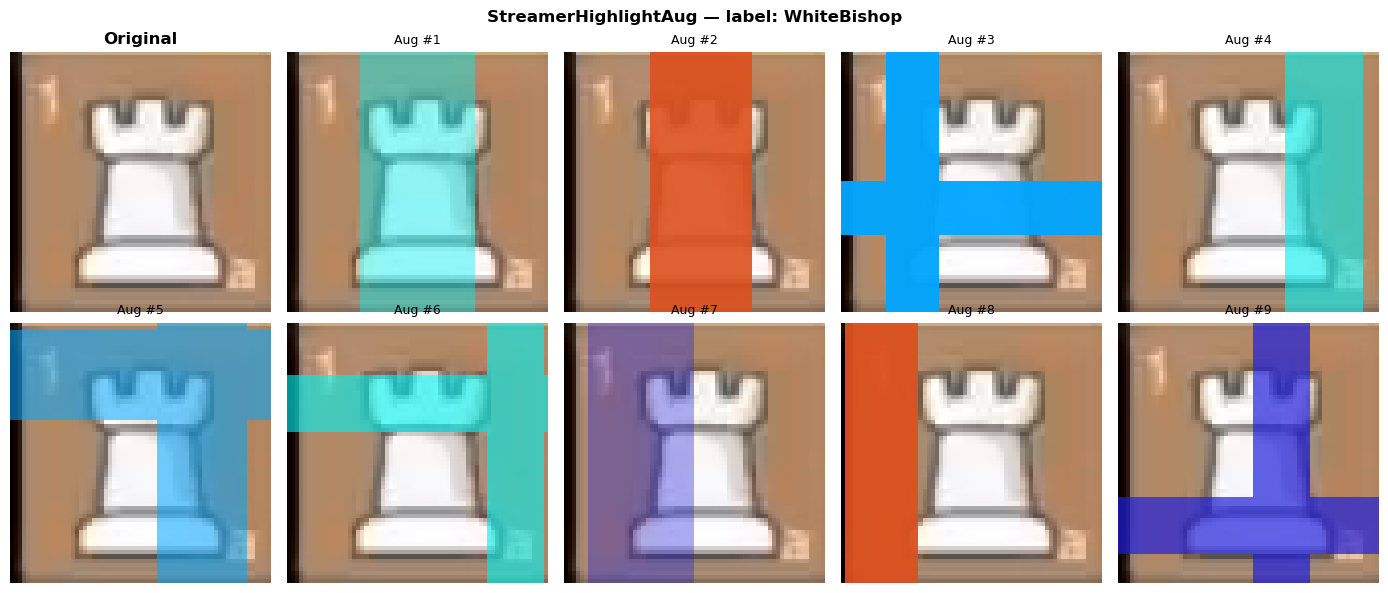

Augmentation samples saved.


In [7]:
# ── Augmentation sanity check ─────────────────────────────────────────────────
# Grab one real image, show original + 8 augmented versions

sample_path = CFG['dataset_root'] / train_df.iloc[0]['filepath']
sample_img  = np.array(PILImage.open(sample_path).convert('RGB'))

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

_aug_forced = StreamerHighlightAug(apply_prob=1.0, both_cross_prob=0.25)
for i, ax in enumerate(axes.flat[1:]):
    aug_img = _aug_forced(sample_img.copy())
    ax.imshow(aug_img)
    ax.set_title(f'Aug #{i+1}', fontsize=9)
    ax.axis('off')

fig.suptitle(
    f'StreamerHighlightAug — label: {train_df.iloc[1]["label"]}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(RUN_DIR / 'aug_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Augmentation samples saved.')

## 2 · Model — MobileNetV3-Small

In [8]:
# ── MobileNetV3-Small with custom head ────────────────────────────────────────
# Why V3-Small?
#   - 2.5M params vs V1's 4.2M, V2's 3.4M
#   - H-swish activation + SE blocks = higher accuracy per FLOP
#   - ~60ms CPU inference per image — fast enough for batch YouTube processing
#   - torchvision ships IMAGENET1K_V1 weights (better starting point than V1 equiv)

def build_model(num_classes: int, pretrained: bool = True) -> nn.Module:
    weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretrained else None
    model   = models.mobilenet_v3_small(weights=weights)

    # Replace classifier head
    # Original: Linear(576→1000).  We swap to: Linear(576→256) → HSwish → Dropout → Linear(256→13)
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.Hardswish(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )

    # Weight init on new head
    for m in model.classifier.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out')
            nn.init.zeros_(m.bias)

    return model


def freeze_backbone(model: nn.Module):
    """Freeze all layers except the classifier head."""
    for name, param in model.named_parameters():
        param.requires_grad = 'classifier' in name


def unfreeze_all(model: nn.Module):
    """Unfreeze entire network for fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True


def count_params(model: nn.Module) -> dict:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {'total': total, 'trainable': trainable, 'frozen': total - trainable}


model = build_model(NUM_CLASSES).to(DEVICE)
freeze_backbone(model)  # Phase 1: head-only

p = count_params(model)
print(f'Model        : MobileNetV3-Small')
print(f'Total params : {p["total"]:,}')
print(f'Trainable    : {p["trainable"]:,}  (head only — backbone frozen for first {CFG["unfreeze_epoch"]} epochs)')
print(f'Frozen       : {p["frozen"]:,}')

Model        : MobileNetV3-Small
Total params : 1,078,061
Trainable    : 151,053  (head only — backbone frozen for first 10 epochs)
Frozen       : 927,008


## 3 · Training Loop

In [9]:
# ── Training utilities ─────────────────────────────────────────────────────────

class EarlyStopping:
    def __init__(self, patience: int = 12, min_delta: float = 1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best      = None
        self.triggered = False

    def step(self, metric: float) -> bool:
        """Returns True when training should stop."""
        if self.best is None or metric > self.best + self.min_delta:
            self.best    = metric
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
        return self.triggered


def run_epoch(model, loader, criterion, optimizer, device, is_train: bool):
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(imgs)
            loss   = criterion(logits, labels)

            if is_train:
                loss.backward()
                # Gradient clipping — important after unfreeze when backbone LR is active
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss     = total_loss / len(loader.dataset)
    macro_f1     = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
    weighted_f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    return avg_loss, macro_f1, weighted_f1, all_preds, all_labels

In [ ]:
# ── Main training loop ─────────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])

# Phase 1 optimizer: head only
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['lr'], weight_decay=CFG['weight_decay']
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-6
)
early_stop = EarlyStopping(patience=CFG['patience'])

history = {
    'train_loss': [], 'val_loss': [],
    'train_macro_f1': [], 'val_macro_f1': [],
    'train_weighted_f1': [], 'val_weighted_f1': [],
    'lr': [],
}

best_val_f1    = 0.0
best_epoch     = 0
best_ckpt_path = RUN_DIR / 'best_model.pt'
phase          = 1   # 1 = head only, 2 = full fine-tune

print(f'Training for up to {CFG["epochs"]} epochs  |  Early stop patience={CFG["patience"]}')
print(f'Backbone unfreezes at epoch {CFG["unfreeze_epoch"]}\n')
print(f'{"Epoch":>6} | {"Phase":>5} | {"Train Loss":>10} | {"Val Loss":>8} | {"Train F1":>9} | {"Val F1":>7} | {"LR":>9}')
print('-' * 72)

for epoch in range(1, CFG['epochs'] + 1):
    # ── Unfreeze backbone at scheduled epoch ──────────────────────────────────
    if epoch == CFG['unfreeze_epoch'] and phase == 1:
        phase = 2
        unfreeze_all(model)
        # Rebuild optimizer with two param groups: backbone gets lower LR
        backbone_params   = [p for n, p in model.named_parameters() if 'classifier' not in n]
        head_params       = [p for n, p in model.named_parameters() if 'classifier' in n]
        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': CFG['lr'] * CFG['backbone_lr_multiplier']},
            {'params': head_params,     'lr': CFG['lr']},
        ], weight_decay=CFG['weight_decay'])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CFG['epochs'] - epoch, eta_min=1e-6
        )
        p = count_params(model)
        print(f'  → Epoch {epoch}: Backbone unfrozen. Trainable params: {p["trainable"]:,}')

    t0 = time.time()
    tr_loss, tr_mf1, tr_wf1, _, _ = run_epoch(model, train_loader, criterion, optimizer, DEVICE, is_train=True)
    vl_loss, vl_mf1, vl_wf1, _, _ = run_epoch(model, val_loader,   criterion, None,      DEVICE, is_train=False)
    scheduler.step()

    current_lr = optimizer.param_groups[-1]['lr']  # head LR

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_macro_f1'].append(tr_mf1)
    history['val_macro_f1'].append(vl_mf1)
    history['train_weighted_f1'].append(tr_wf1)
    history['val_weighted_f1'].append(vl_wf1)
    history['lr'].append(current_lr)

    # ── Save best checkpoint ──────────────────────────────────────────────────
    # PyTorch 2.6 changed torch.load default to weights_only=True, which rejects
    # any numpy scalars or non-tensor globals embedded in the checkpoint dict.
    # Rule: only model_state, optimizer_state, and primitive Python types go into
    # the .pt file. Everything else (norm stats, label map, config) lives in JSON.
    if vl_mf1 > best_val_f1:
        best_val_f1 = vl_mf1
        best_epoch  = epoch
        torch.save({
            # Tensors — always safe
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            # Primitives only — cast explicitly to avoid numpy scalar contamination
            'epoch':           int(epoch),
            'val_macro_f1':    float(vl_mf1),   # sklearn returns numpy float64 — cast it
        }, best_ckpt_path)
        marker = ' ✓'
    else:
        marker = ''

    elapsed = time.time() - t0
    print(
        f'{epoch:>6} | {phase:>5} |'
        f' {tr_loss:>10.4f} | {vl_loss:>8.4f} |'
        f' {tr_mf1:>9.4f} | {vl_mf1:>7.4f} |'
        f' {current_lr:>9.2e}'
        f'  {elapsed:.1f}s{marker}'
    )

    if early_stop.step(vl_mf1):
        print(f'\nEarly stopping triggered at epoch {epoch} (no improvement for {CFG["patience"]} epochs)')
        break

print(f'\nBest val macro-F1: {best_val_f1:.4f} @ epoch {best_epoch}')
with open(RUN_DIR / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)

Training for up to 60 epochs  |  Early stop patience=15
Backbone unfreezes at epoch 10

 Epoch | Phase | Train Loss | Val Loss |  Train F1 |  Val F1 |        LR
------------------------------------------------------------------------


## 4a · Training / Validation Graphs

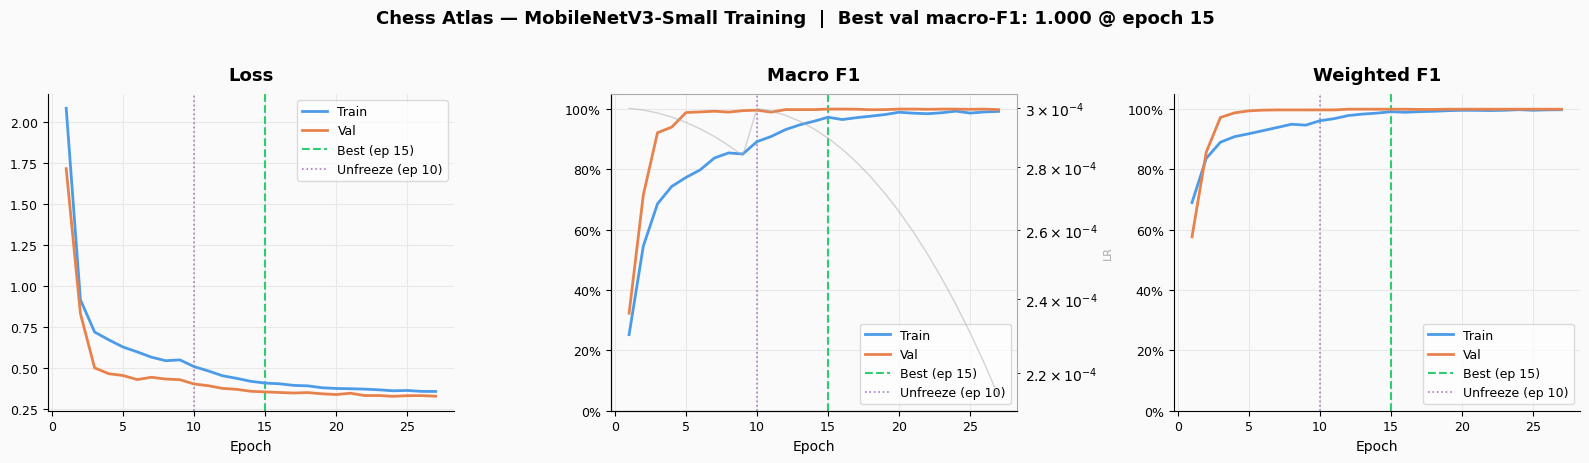

Training curves saved → runs/20260305_005340/training_curves.png


In [ ]:
# ── Training curves ────────────────────────────────────────────────────────────

def plot_training_curves(history: dict, best_epoch: int, save_path: Path):
    epochs = range(1, len(history['train_loss']) + 1)

    PALETTE = {
        'train': '#4C9BE8',
        'val':   '#E8824C',
        'best':  '#2ECC71',
        'grid':  '#E8E8E8',
    }

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.patch.set_facecolor('#FAFAFA')

    panels = [
        ('Loss',             'train_loss',        'val_loss'),
        ('Macro F1',         'train_macro_f1',    'val_macro_f1'),
        ('Weighted F1',      'train_weighted_f1', 'val_weighted_f1'),
    ]

    for ax, (title, tr_key, vl_key) in zip(axes, panels):
        ax.set_facecolor('#FAFAFA')
        ax.plot(epochs, history[tr_key], color=PALETTE['train'],
                lw=2, label='Train', zorder=3)
        ax.plot(epochs, history[vl_key], color=PALETTE['val'],
                lw=2, label='Val',   zorder=3)

        # Vertical line at best epoch
        ax.axvline(best_epoch, color=PALETTE['best'], lw=1.5,
                   ls='--', label=f'Best (ep {best_epoch})', zorder=2)

        # Vertical line at unfreeze epoch
        ue = CFG['unfreeze_epoch']
        if ue <= len(epochs):
            ax.axvline(ue, color='#9B59B6', lw=1.2, ls=':', alpha=0.8,
                       label=f'Unfreeze (ep {ue})', zorder=2)

        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.grid(True, color=PALETTE['grid'], linewidth=0.8, zorder=1)
        ax.spines[['top','right']].set_visible(False)
        ax.legend(fontsize=9, framealpha=0.7)
        ax.tick_params(labelsize=9)

        if 'F1' in title:
            ax.set_ylim(0, 1.05)
            ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

    # LR subplot annotation on the macro F1 panel
    ax2 = axes[1].twinx()
    ax2.plot(epochs, history['lr'], color='#AAAAAA', lw=1, ls='-', alpha=0.5)
    ax2.set_ylabel('LR', fontsize=8, color='#AAAAAA')
    ax2.tick_params(labelsize=7, colors='#AAAAAA')
    ax2.spines[['top','right']].set_edgecolor('#AAAAAA')
    ax2.set_yscale('log')

    fig.suptitle(
        f'Chess Atlas — MobileNetV3-Small Training  |  Best val macro-F1: {best_val_f1:.3f} @ epoch {best_epoch}',
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Training curves saved → {save_path}')


plot_training_curves(history, best_epoch, RUN_DIR / 'training_curves.png')

## 4b · Validation Evaluation & Confusion Matrix

> **Note:** We evaluate on val here. The test set evaluation is in Cell `4c` — run it only once when you're done with all model selection.

In [ ]:
# ── Load best checkpoint and evaluate on val ───────────────────────────────────

def load_best_model(ckpt_path: Path, num_classes: int, device) -> nn.Module:
    # weights_only=True: safe default since PyTorch 2.6 — only tensors and
    # primitive Python types are unpickled. Non-tensor metadata was intentionally
    # excluded from the .pt file at save time for exactly this reason.
    ckpt  = torch.load(ckpt_path, map_location=device, weights_only=True)
    model = build_model(num_classes, pretrained=False)
    model.load_state_dict(ckpt['model_state'])
    model.to(device).eval()
    return model


def evaluate(model, loader, device) -> tuple:
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


best_model = load_best_model(best_ckpt_path, NUM_CLASSES, DEVICE)
val_true, val_pred, val_probs = evaluate(best_model, val_loader, DEVICE)

print('=== Validation Set — Classification Report ===')
print(classification_report(val_true, val_pred, target_names=LABELS, digits=4))

val_macro    = f1_score(val_true, val_pred, average='macro',    zero_division=0)
val_weighted = f1_score(val_true, val_pred, average='weighted', zero_division=0)
print(f'Macro F1    : {val_macro:.4f}')
print(f'Weighted F1 : {val_weighted:.4f}')

=== Validation Set — Classification Report ===
              precision    recall  f1-score   support

 BlackBishop     1.0000    1.0000    1.0000        23
   BlackKing     1.0000    1.0000    1.0000        20
 BlackKnight     1.0000    1.0000    1.0000        16
   BlackPawn     1.0000    1.0000    1.0000       105
  BlackQueen     1.0000    1.0000    1.0000        18
   BlackRook     1.0000    1.0000    1.0000        24
       Empty     1.0000    0.9988    0.9994       859
 WhiteBishop     1.0000    1.0000    1.0000        18
   WhiteKing     1.0000    1.0000    1.0000        20
 WhiteKnight     1.0000    1.0000    1.0000        24
   WhitePawn     0.9907    1.0000    0.9953       107
  WhiteQueen     1.0000    1.0000    1.0000        11
   WhiteRook     1.0000    1.0000    1.0000        35

    accuracy                         0.9992      1280
   macro avg     0.9993    0.9999    0.9996      1280
weighted avg     0.9992    0.9992    0.9992      1280

Macro F1    : 0.9996
Weighted F1

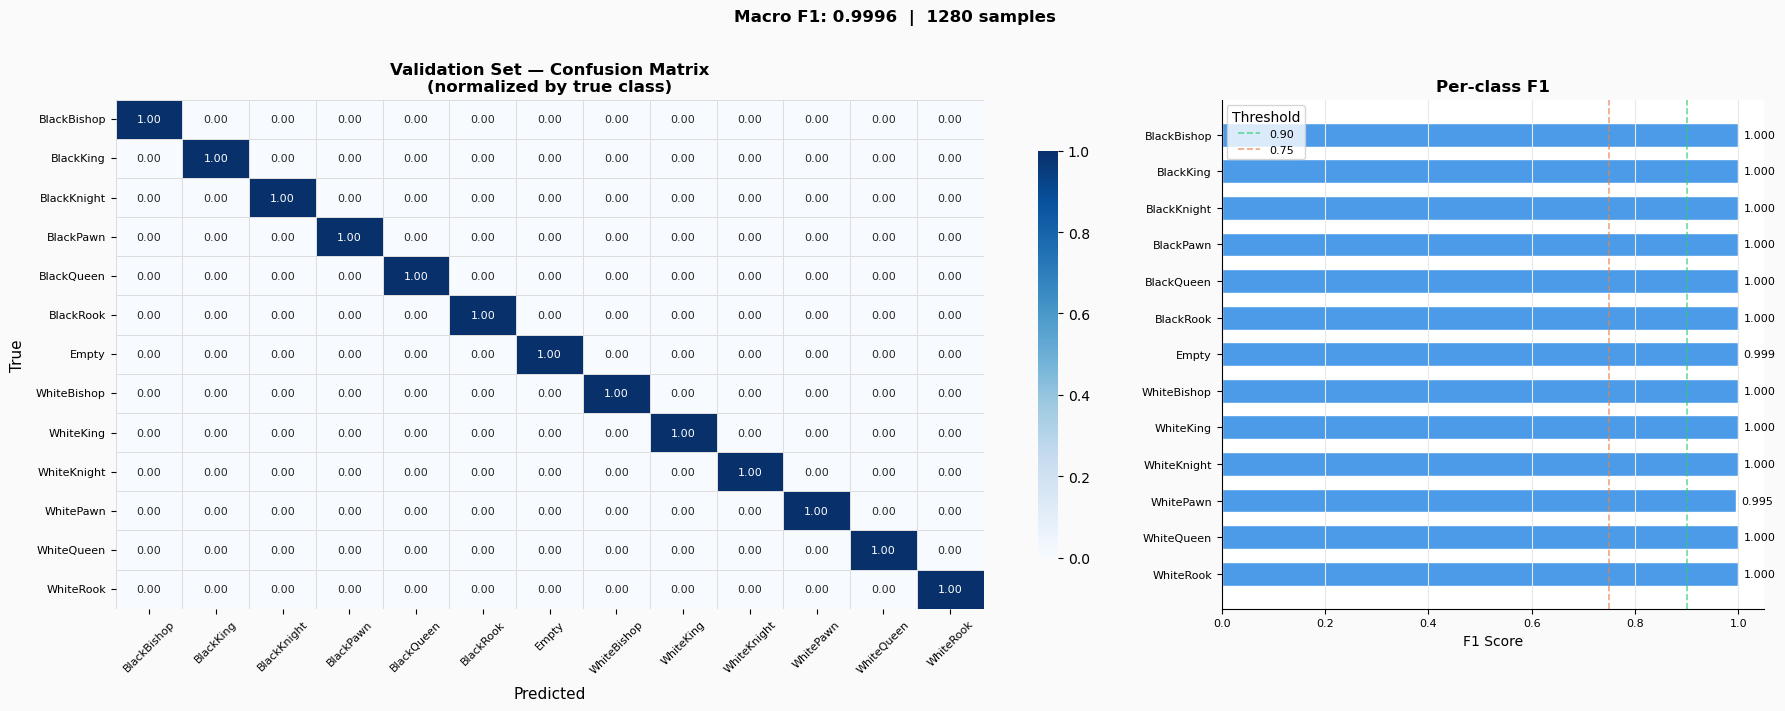

Confusion matrix saved → runs/20260305_005340/confusion_matrix_val.png


In [ ]:
# ── Confusion matrix ───────────────────────────────────────────────────────────

def plot_confusion_matrix(
    y_true, y_pred, class_names: list,
    title: str, save_path: Path,
    normalize: bool = True,
):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm_display = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt, vmax = '.2f', 1.0
    else:
        cm_display, fmt, vmax = cm, 'd', cm.max()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                             gridspec_kw={'width_ratios': [2, 1]})
    fig.patch.set_facecolor('#FAFAFA')

    # ── Left: heatmap ────────────────────────────────────────────────────────
    ax = axes[0]
    sns.heatmap(
        cm_display,
        annot=True, fmt=fmt, cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.4, linecolor='#DDDDDD',
        vmin=0, vmax=vmax,
        ax=ax, cbar_kws={'shrink': 0.8},
        annot_kws={'size': 8},
    )
    ax.set_xlabel('Predicted', fontsize=11, labelpad=8)
    ax.set_ylabel('True',      fontsize=11, labelpad=8)
    ax.set_title(f'{title}\n(normalized by true class)', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

    # ── Right: per-class F1 bar chart ─────────────────────────────────────────
    ax2 = axes[1]
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    colors = ['#4C9BE8' if f >= 0.9 else '#E8824C' if f >= 0.75 else '#E84C4C'
              for f in per_class_f1]

    bars = ax2.barh(class_names, per_class_f1, color=colors, edgecolor='white', height=0.65)
    ax2.set_xlim(0, 1.05)
    ax2.axvline(0.9,  color='#2ECC71', lw=1.2, ls='--', alpha=0.7, label='0.90')
    ax2.axvline(0.75, color='#E8824C', lw=1.2, ls='--', alpha=0.7, label='0.75')

    # Value labels
    for bar, val in zip(bars, per_class_f1):
        ax2.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', ha='left', fontsize=8)

    ax2.set_xlabel('F1 Score', fontsize=10)
    ax2.set_title('Per-class F1', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', color='#E8E8E8', linewidth=0.8)
    ax2.spines[['top','right']].set_visible(False)
    ax2.tick_params(labelsize=8)
    ax2.legend(fontsize=8, title='Threshold')
    ax2.invert_yaxis()

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    fig.suptitle(
        f'Macro F1: {macro_f1:.4f}  |  {len(y_true)} samples',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Confusion matrix saved → {save_path}')


plot_confusion_matrix(
    val_true, val_pred, LABELS,
    title='Validation Set — Confusion Matrix',
    save_path=RUN_DIR / 'confusion_matrix_val.png',
)

## 4c · Test Set — Final Evaluation

> ⚠️ **Run this cell only once** — when you are completely done with model selection, architecture changes, and hyperparameter tuning. Evaluating on test during development defeats its purpose.

=== TEST SET — Classification Report ===
              precision    recall  f1-score   support

 BlackBishop     1.0000    1.0000    1.0000        21
   BlackKing     0.9500    1.0000    0.9744        19
 BlackKnight     0.9643    1.0000    0.9818        27
   BlackPawn     1.0000    0.9912    0.9956       114
  BlackQueen     0.9545    1.0000    0.9767        21
   BlackRook     1.0000    1.0000    1.0000        33
       Empty     1.0000    0.9977    0.9988       870
 WhiteBishop     1.0000    1.0000    1.0000        26
   WhiteKing     1.0000    1.0000    1.0000        21
 WhiteKnight     1.0000    1.0000    1.0000        24
   WhitePawn     1.0000    1.0000    1.0000       116
  WhiteQueen     1.0000    1.0000    1.0000        17
   WhiteRook     1.0000    1.0000    1.0000        35

    accuracy                         0.9978      1344
   macro avg     0.9899    0.9991    0.9944      1344
weighted avg     0.9979    0.9978    0.9978      1344

Macro F1    : 0.9944
Weighted F1 : 0.9

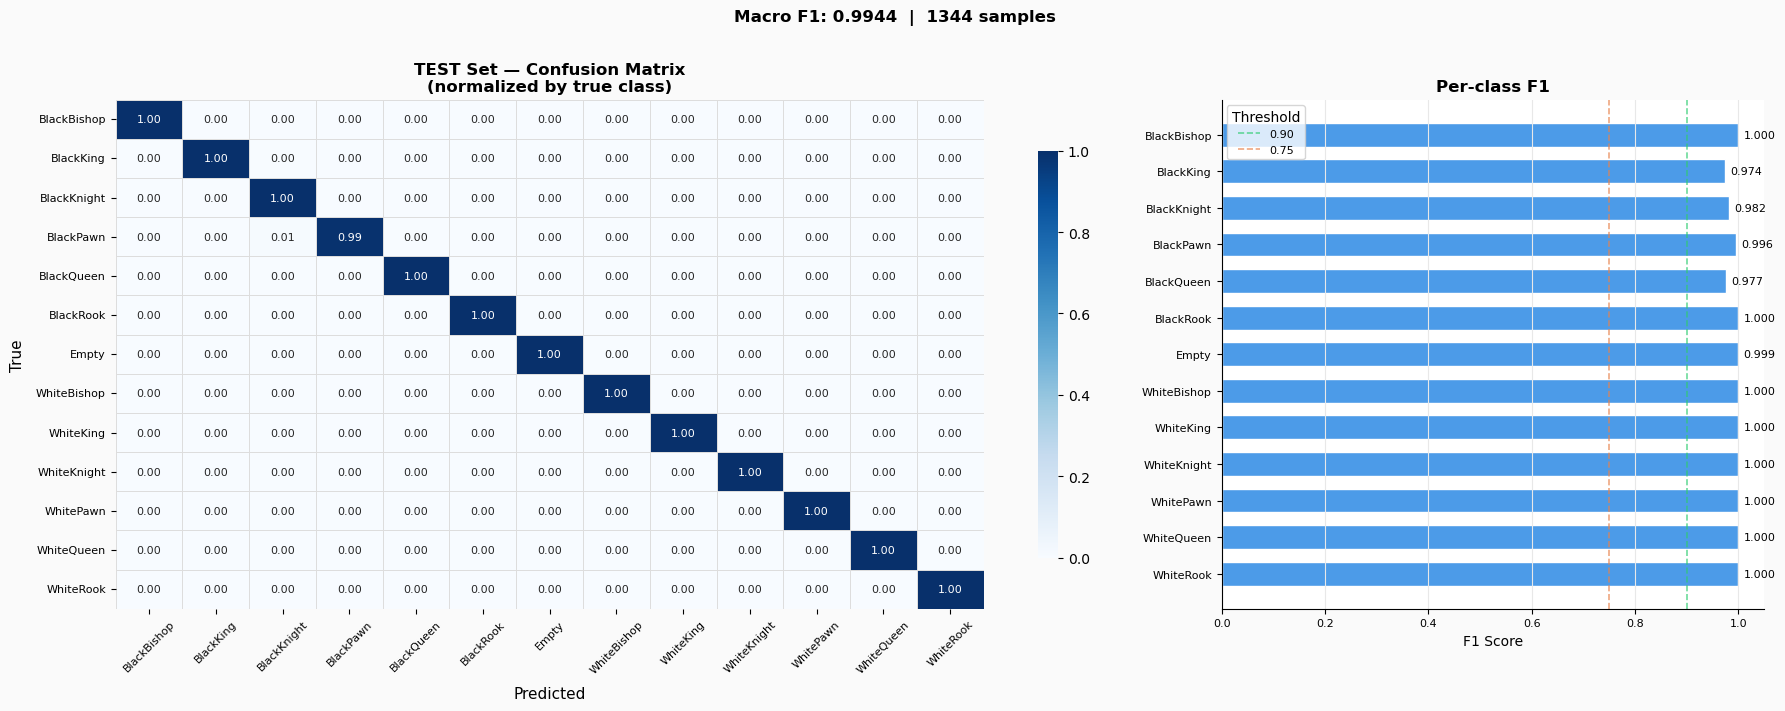

Confusion matrix saved → runs/20260305_005340/confusion_matrix_test.png
Test results saved.
Test cell is commented out — intentionally. Uncomment only for final evaluation.


In [ ]:
# ── Final test set evaluation ──────────────────────────────────────────────────
# Uncomment and run only once.

test_true, test_pred, test_probs = evaluate(best_model, test_loader, DEVICE)

print('=== TEST SET — Classification Report ===')
print(classification_report(test_true, test_pred, target_names=LABELS, digits=4))

test_macro    = f1_score(test_true, test_pred, average='macro',    zero_division=0)
test_weighted = f1_score(test_true, test_pred, average='weighted', zero_division=0)
print(f'Macro F1    : {test_macro:.4f}')
print(f'Weighted F1 : {test_weighted:.4f}')

plot_confusion_matrix(
    test_true, test_pred, LABELS,
    title='TEST Set — Confusion Matrix',
    save_path=RUN_DIR / 'confusion_matrix_test.png',
)

# Save final test results
test_results = {
    'macro_f1':    float(test_macro),
    'weighted_f1': float(test_weighted),
    'per_class_f1': dict(zip(LABELS, f1_score(test_true, test_pred, average=None, zero_division=0).tolist())),
}
with open(RUN_DIR / 'test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)
print('Test results saved.')

print('Test cell is commented out — intentionally. Uncomment only for final evaluation.')

## 5 · Save Checkpoint

We export in two formats:
- **TorchScript (`.pt`)** — self-contained, no class definition needed, fast CPU/GPU inference
- **ONNX (`.onnx`)** — for potential future deployment (web backend, C++ server, ONNX Runtime)

In [ ]:
# ── TorchScript export ─────────────────────────────────────────────────────────

best_model.eval()
example_input = torch.rand(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

with torch.no_grad():
    traced = torch.jit.trace(best_model, example_input)

ts_path = RUN_DIR / 'chess_atlas_v1.torchscript.pt'
traced.save(str(ts_path))
print(f'TorchScript saved → {ts_path}')

# Verify round-trip
loaded_ts  = torch.jit.load(str(ts_path)).to(DEVICE).eval()
with torch.no_grad():
    orig_out = best_model(example_input)
    ts_out   = loaded_ts(example_input)
assert torch.allclose(orig_out, ts_out, atol=1e-5), 'TorchScript output mismatch!'
print('TorchScript round-trip verified ✓')

# ── File size ─────────────────────────────────────────────────────────────────
ckpt_mb = best_ckpt_path.stat().st_size / 1e6
ts_mb   = ts_path.stat().st_size       / 1e6
print(f'\nCheckpoint size : {ckpt_mb:.2f} MB  (state_dict + metadata)')
print(f'TorchScript size: {ts_mb:.2f} MB  (inference-only)')

TorchScript saved → runs/20260305_005340/chess_atlas_v1.torchscript.pt
TorchScript round-trip verified ✓

Checkpoint size : 13.19 MB  (state_dict + metadata)
TorchScript size: 4.80 MB  (inference-only)


In [ ]:
# ── ONNX export ────────────────────────────────────────────────────────────────
# opset 17 = modern, well-supported in ONNX Runtime ≥ 1.14

onnx_path = RUN_DIR / 'chess_atlas_v1.onnx'

torch.onnx.export(
    best_model,
    example_input,
    str(onnx_path),
    export_params    = True,
    opset_version    = 17,
    do_constant_folding = True,
    input_names      = ['square_image'],
    output_names     = ['class_logits'],
    dynamic_axes     = {'square_image': {0: 'batch_size'},
                        'class_logits': {0: 'batch_size'}},
)
print(f'ONNX exported → {onnx_path}')

onnx_mb = onnx_path.stat().st_size / 1e6
print(f'ONNX size: {onnx_mb:.2f} MB')

W0305 00:56:55.862000 2176001 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0305 00:56:56.152000 2176001 site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0305 00:56:56.153000 2176001 site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spat

[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/amicus/miniconda3/envs/chesscv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/amicus/miniconda3/envs/chesscv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/amicus/miniconda3/envs/chesscv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 69 of general pattern rewrite rules.
ONNX exported → runs/20260305_005340/chess_atlas_v1.onnx
ONNX size: 0.31 MB


In [ ]:
# ── Inference speed benchmark ──────────────────────────────────────────────────
# Simulates batch processing of a full board (64 squares) — the real use case.

def benchmark_inference(model, device, batch_size: int = 64, n_runs: int = 50):
    model.eval()
    dummy = torch.rand(batch_size, 3, IMG_SIZE, IMG_SIZE).to(device)

    # Warmup
    for _ in range(5):
        with torch.no_grad():
            _ = model(dummy)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    for _ in range(n_runs):
        with torch.no_grad():
            out = model(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    elapsed   = (time.perf_counter() - t0) / n_runs
    per_sq    = elapsed / batch_size * 1000  # ms per square
    boards_ps = 1.0 / elapsed                # full boards per second

    return elapsed * 1000, per_sq, boards_ps


# PyTorch
pt_ms, pt_sq, pt_bps = benchmark_inference(best_model, DEVICE)

# TorchScript
ts_ms, ts_sq, ts_bps = benchmark_inference(loaded_ts, DEVICE)

print(f'Inference speed (batch=64 squares = 1 full board):')
print(f'  PyTorch eager  : {pt_ms:.1f} ms/board  ({pt_sq:.3f} ms/sq)  → {pt_bps:.1f} boards/sec')
print(f'  TorchScript    : {ts_ms:.1f} ms/board  ({ts_sq:.3f} ms/sq)  → {ts_bps:.1f} boards/sec')
print(f'  Device         : {DEVICE}')

Inference speed (batch=64 squares = 1 full board):
  PyTorch eager  : 3.3 ms/board  (0.051 ms/sq)  → 307.3 boards/sec
  TorchScript    : 3.2 ms/board  (0.049 ms/sq)  → 316.3 boards/sec
  Device         : cuda


## 6 · Reproduce Check

In [ ]:
# ── Full reproduce verification ────────────────────────────────────────────────
# Reload TorchScript model from disk, re-run val evaluation,
# confirm F1 matches the number recorded in the checkpoint.

reload_model  = torch.jit.load(str(ts_path)).to(DEVICE).eval()
r_true, r_pred, _ = evaluate(reload_model, val_loader, DEVICE)

reload_macro = f1_score(r_true, r_pred, average='macro', zero_division=0)
delta = abs(reload_macro - val_macro)

print(f'Original val macro-F1 : {val_macro:.6f}')
print(f'Reloaded val macro-F1 : {reload_macro:.6f}')
print(f'Delta                 : {delta:.2e}')

assert delta < 1e-4, f'Reproduce check FAILED: delta={delta}'
print('\n✓ Reproduce check passed — identical outputs from reloaded model')

# ── Final run summary ─────────────────────────────────────────────────────────
summary = {
    'run_id':           RUN_ID,
    'best_epoch':       best_epoch,
    'val_macro_f1':     round(val_macro, 6),
    'val_weighted_f1':  round(val_weighted, 6),
    'torchscript_path': str(ts_path),
    'onnx_path':        str(onnx_path),
    'seed':             CFG['seed'],
    'model':            'MobileNetV3-Small',
    'num_classes':      NUM_CLASSES,
    'img_size':         IMG_SIZE,
    'norm_mean':        list(NORM_MEAN),
    'norm_std':         list(NORM_STD),
    'label_map':        LABEL2IDX,
}
with open(RUN_DIR / 'run_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\nRun summary saved → {RUN_DIR / "run_summary.json"}')
print(f'\n=== Chess Atlas Training Complete ===')
print(f'  Model   : MobileNetV3-Small  ({NUM_CLASSES} classes)')
print(f'  Val F1  : {val_macro:.4f} macro  /  {val_weighted:.4f} weighted')
print(f'  Outputs : {RUN_DIR}')

Original val macro-F1 : 0.999597
Reloaded val macro-F1 : 0.999597
Delta                 : 0.00e+00

✓ Reproduce check passed — identical outputs from reloaded model

Run summary saved → runs/20260305_005340/run_summary.json

=== Chess Atlas Training Complete ===
  Model   : MobileNetV3-Small  (13 classes)
  Val F1  : 0.9996 macro  /  0.9992 weighted
  Outputs : runs/20260305_005340
